# Manufacturing Defect Detection using Machine Learning

## Aim

The objective of this project is to design an end-to-end machine learning pipeline for detecting manufacturing defects from product images. The pipeline includes image preprocessing, data augmentation, CNN model training, evaluation, and deployment considerations.


In [1]:
from google.colab import files

uploaded = files.upload()

Saving dataset.zip to dataset.zip


## Extract Dataset

The uploaded ZIP file is extracted to access the training images.

In [3]:
import zipfile

with zipfile.ZipFile("dataset.zip", "r") as zip_ref:
    zip_ref.extractall()

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [7]:
import os

for root, dirs, files in os.walk("."):
    print(root)

.
./.config
./.config/configurations
./.config/logs
./.config/logs/2026.06.04
./rice_leaf_diseases
./rice_leaf_diseases/Brown spot
./rice_leaf_diseases/Leaf smut
./rice_leaf_diseases/Bacterial leaf blight
./sample_data


## Import Required Libraries

The following libraries are required for image preprocessing, augmentation, model training and evaluation.

In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Dataset Structure

The dataset should be organized as follows:

dataset/

├── Defective/

└── OK/

In [9]:
dataset_path="rice_leaf_diseases"

print(os.listdir(dataset_path))

['Brown spot', 'Leaf smut', 'Bacterial leaf blight']


In [10]:
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [11]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

## Load Training and Validation Data

The dataset is split into training (80%) and validation (20%) using ImageDataGenerator.

In [12]:
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=16,
    class_mode="categorical",
    subset="training"
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=16,
    class_mode="categorical",
    subset="validation"
)

Found 96 images belonging to 3 classes.
Found 24 images belonging to 3 classes.


## Build CNN Model

A simple Convolutional Neural Network (CNN) is created for image classification.

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense

model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)))
model.add(MaxPooling2D())

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(128,activation='relu'))

model.add(Dense(3,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Compile the Model

The CNN model is compiled using the Adam optimizer, categorical cross-entropy loss function, and accuracy as the evaluation metric.

In [14]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

## Train the Model

The CNN model is trained using the training dataset and evaluated using the validation dataset.

In [15]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.3229 - loss: 2.9189 - val_accuracy: 0.3333 - val_loss: 1.3593
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 690ms/step - accuracy: 0.3958 - loss: 1.1730 - val_accuracy: 0.3333 - val_loss: 1.1584
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 899ms/step - accuracy: 0.3646 - loss: 1.1072 - val_accuracy: 0.3750 - val_loss: 1.1372
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 665ms/step - accuracy: 0.3229 - loss: 1.0537 - val_accuracy: 0.2500 - val_loss: 1.1680
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 805ms/step - accuracy: 0.3542 - loss: 1.0224 - val_accuracy: 0.2500 - val_loss: 1.2667
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 706ms/step - accuracy: 0.5625 - loss: 0.9618 - val_accuracy: 0.3750 - val_loss: 1.3215
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 678ms/step - accuracy: 0.5729 - loss: 0.9041 - val_accuracy: 0.4583 - val_loss: 1.1060
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 936ms/step - accuracy: 0.5417 - loss: 0.8951 - val_accuracy: 0.6250 - val_loss: 0.

## Evaluate the Model

The trained model is evaluated using the validation dataset.

In [16]:
loss, accuracy = model.evaluate(validation_generator)

print("Validation Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 238ms/step - accuracy: 0.5417 - loss: 0.8419
Validation Accuracy: 0.5416666865348816


## Plot Training and Validation Accuracy

The graph compares training accuracy and validation accuracy across all epochs.

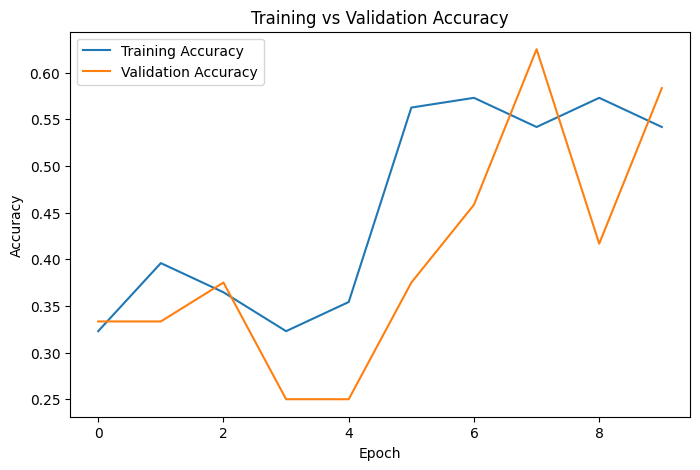

In [17]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label="Training Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

## Save the Trained Model

The trained CNN model is saved for future prediction and deployment.

In [18]:
model.save("rice_leaf_model.h5")

print("Model Saved Successfully")

Model Saved Successfully


# Deployment Considerations

The trained model can be deployed using the following platforms:

- Flask Web Application
- FastAPI REST API
- Streamlit Dashboard
- TensorFlow Lite for Mobile Devices
- Raspberry Pi
- Edge AI Systems

The deployed system can automatically classify rice leaf diseases from uploaded images and assist farmers in early disease detection.

# Deployment Considerations

The trained model can be deployed using the following platforms:

- Flask Web Application
- FastAPI REST API
- Streamlit Dashboard
- TensorFlow Lite for Mobile Devices
- Raspberry Pi
- Edge AI Systems

The deployed system can automatically classify rice leaf diseases from uploaded images and assist farmers in early disease detection.